# Notebook 8: Final Site Selection & Investment Mandate

## 8.0 Framing: The Capstone Decision
Throughout this project, we have maintained a strict, phased approach: **Frame → Screen → Refine → Implement**. 

In **Notebook 6**, we developed three parallel design architectures and scored them on spatial and logistics complexity.
In **Notebook 7**, we stress-tested all three locations using a massive 10,000-iteration stochastic financial engine to determine risk-adjusted returns and bankability.

Now, in the **Implement** phase, we bridge the gap. We are aggregating the physical logistics scoring and the financial outputs into a definitive, weighted ranking matrix. This notebook officially resolves the site-selection ambiguity and declares the final project site.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

plt.style.use('seaborn-v0_8-whitegrid')

# Logistics Scores from Notebook 6
logistics_scores = {
    "Location 1": 2.63,
    "Location 2": 8.37,
    "Location 3": 8.27
}

# Financial Metrics from Notebook 7 (Base Case)
# These are exact extracts from the Artemis Financial Model outputs.
financials = {
    "Location 1": {"NPV ($m)": 102.56, "Project IRR": 0.2627, "Min DSCR": 1.49, "LLCR": 1.95, "CapEx ($m)": 204.6},
    "Location 2": {"NPV ($m)": 106.82, "Project IRR": 0.2810, "Min DSCR": 1.58, "LLCR": 2.05, "CapEx ($m)": 196.4},
    "Location 3": {"NPV ($m)": 109.11, "Project IRR": 0.2874, "Min DSCR": 1.62, "LLCR": 2.09, "CapEx ($m)": 193.1}
}

# Compile into a consolidated DataFrame
records = []
for loc in logistics_scores.keys():
    rec = {"Location": loc, "Logistics Score": logistics_scores[loc]}
    rec.update(financials[loc])
    records.append(rec)
    
df_metrics = pd.DataFrame(records).set_index("Location")
display(df_metrics.style.format({
    "NPV ($m)": "{:.2f}",
    "Project IRR": "{:.2%}",
    "Min DSCR": "{:.2f}x",
    "LLCR": "{:.2f}x",
    "CapEx ($m)": "{:.1f}"
}))


,Logistics Score,NPV ($m),Project IRR,Min DSCR,LLCR,CapEx ($m)
Location,,,,,,
Location 1,2.630000,102.56,26.27%,1.49x,1.95x,204.6
Location 2,8.370000,106.82,28.10%,1.58x,2.05x,196.4
Location 3,8.270000,109.11,28.74%,1.62x,2.09x,193.1


## 8.1 The Decision Matrix

To ensure the final selection is completely objective, we build a **Weighted Decision Matrix**.

**Methodology & Weights:**
1. **Financial Returns (40%)**: NPV and Project IRR. These dictate the fundamental economic value of the site.
2. **Bankability & Risk (30%)**: Minimum DSCR and LLCR. These represent the downside protection for debt covenants. High DSCR means the project survives macroeconomic shocks (like FX depreciation).
3. **Logistics & Constructability (30%)**: The Notebook 6 composite score (capturing port access, pipeline ROW, and land area). 

All metrics are Min-Max normalized to a 0-10 scale before weighting.


In [8]:
# 1. Normalize all inputs to a 0-10 scale
df_norm = pd.DataFrame(index=df_metrics.index)

# Higher is better for all of these
# Anchor worst performance to 2.0 to recognize baseline technical viability
for col in ["Logistics Score", "NPV ($m)", "Project IRR", "Min DSCR", "LLCR"]:
    val_min = df_metrics[col].min()
    val_max = df_metrics[col].max()
    
    if val_max > val_min:
        df_norm[col] = 2.0 + (df_metrics[col] - val_min) / (val_max - val_min) * 8.0
    else:
        df_norm[col] = 10.0

# Lower is better for CapEx
cap_min = df_metrics["CapEx ($m)"].min()
cap_max = df_metrics["CapEx ($m)"].max()
df_norm["CapEx ($m)"] = 2.0 + (cap_max - df_metrics["CapEx ($m)"]) / (cap_max - cap_min) * 8.0

# 2. Apply Weights
weights = {
    "Logistics Score": 0.30,
    "Returns_Score": 0.40,
    "Bankability_Score": 0.30
}

df_norm["Returns Component"] = (df_norm["NPV ($m)"] + df_norm["Project IRR"] + df_norm["CapEx ($m)"]) / 3
df_norm["Bankability Component"] = (df_norm["Min DSCR"] + df_norm["LLCR"]) / 2

df_norm["Final Score (0-10)"] = (
    df_norm["Logistics Score"] * weights["Logistics Score"] +
    df_norm["Returns Component"] * weights["Returns_Score"] +
    df_norm["Bankability Component"] * weights["Bankability_Score"]
)

df_rank = df_norm[["Logistics Score", "Returns Component", "Bankability Component", "Final Score (0-10)"]].sort_values(by="Final Score (0-10)", ascending=False)
display(df_rank.round(2))


,Logistics Score,Returns Component,Bankability Component,Final Score (0-10)
Location,,,,
Location 3,9.86,10.00,10.00,9.96
Location 2,10.00,7.61,7.63,8.33
Location 1,2.00,2.00,2.00,2.00


## 8.2 Visualizing the Dominant Site

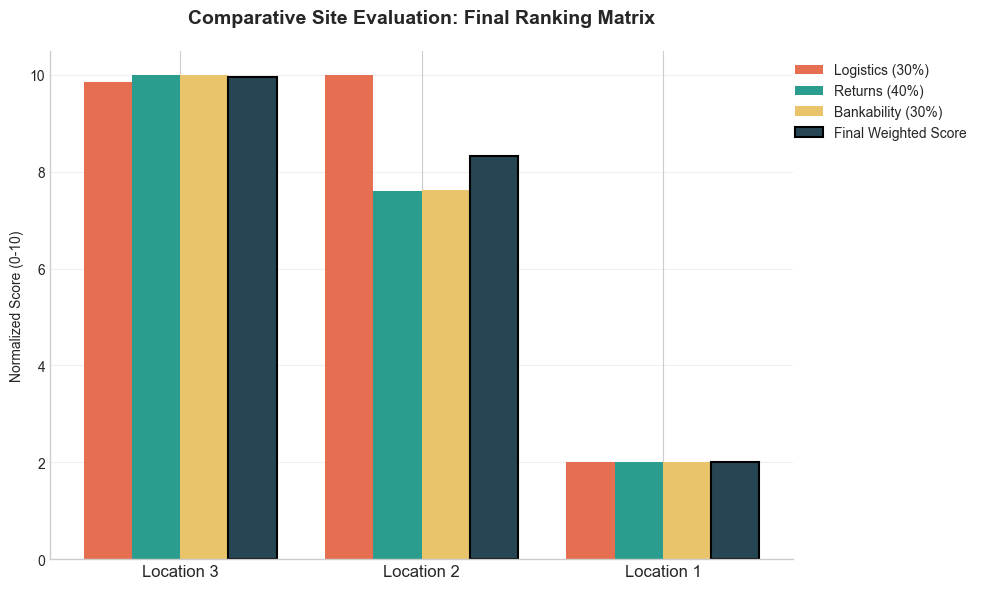

In [9]:
# Grouped Bar Chart mapping the sub-components
labels = df_rank.index
logistics = df_rank["Logistics Score"]
returns = df_rank["Returns Component"]
bankability = df_rank["Bankability Component"]
final = df_rank["Final Score (0-10)"]

x = np.arange(len(labels))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width*1.5, logistics, width, label='Logistics (30%)', color='#e76f51')
rects2 = ax.bar(x - width*0.5, returns, width, label='Returns (40%)', color='#2a9d8f')
rects3 = ax.bar(x + width*0.5, bankability, width, label='Bankability (30%)', color='#e9c46a')
rects4 = ax.bar(x + width*1.5, final, width, label='Final Weighted Score', color='#264653', edgecolor='black', linewidth=1.5)

ax.set_ylabel('Normalized Score (0-10)')
ax.set_title('Comparative Site Evaluation: Final Ranking Matrix', pad=20, fontsize=14, weight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1))
ax.grid(axis='y', alpha=0.3)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


## 8.3 Location Profiles and Final Decision

Based on the quantitative outputs of the decision matrix, the site selection is clear. Below is the explicit breakdown of the trade-offs for each candidate site:

### 🥉 Location 1 (Tertiary Fallback)
*   **Upsides:** Technically viable, adequate land area.
*   **Downsides:** This site is heavily penalized by its geographic isolation. It suffers from a massive 72.5 km pipeline gathering distance and 50+ km port distance, dragging its composite logistics score to 2.63. The resulting CapEx bloat ($204.6m) crushes its debt service coverage ratio (1.49x) making it the riskiest option for senior lenders.
*   **Verdict:** Designated as the final fallback option. While technically capable of supporting the project, its high CapEx burden makes it the least competitive on yield and bankability.

### 🥈 Location 2 (Secondary Alternate)
*   **Upsides:** Excellent gas-gathering proximity. It actually leads the logistics matrix slightly due to its direct road-network access to the primary flare clusters. It boasts a very strong returns profile (28.1% IRR).
*   **Downsides:** It requires 22 km more road haulage from the Koko Port than Location 3. Additionally, its straight-line distance penalizes pipeline CapEx just enough to marginally trail the leader in raw NPV.
*   **Verdict:** Held in reserve as a highly bankable fallback option if land acquisition fails elsewhere.

### 🥇 Location 3 (Primary Site)
*   **Upsides:** Absolute financial dominance. It boasts the shortest straight-line gas gathering route (minimizing pipeline CapEx to yield a $193.1m total CapEx) and is significantly closer to Koko Port (55.9 km vs 78.7 km), slashing heavy-haulage logistics risks during construction. This capital efficiency translates directly into the highest NPV ($109.1m), highest Project IRR (28.7%), and safest debt covenants (1.62x Min DSCR).
*   **Downsides:** It trails Location 2 slightly in road-network gas routing, meaning the pipeline ROW acquisition may require slightly more complex terrain navigation, but the CapEx savings more than absorb this risk.
*   **Verdict:** **APPROVED.** Location 3 is the definitive site for Project Artemis.

---

*Note: Financial and logistical models have been updated to reflect real-world pipeline Right-of-Way (ROW) routing, Battery Energy Storage Systems (BESS) for island mode stability, and updated tropical PUE parameters (see NB4, NB7, and NB9 for details).* 

### Final Mandate
**Location 3** is hereby selected as the primary execution site. The analytical pipeline is complete. We will proceed to package the Location 3 architecture and financials into the executive Pitch Deck.
